In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

import math

import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv('monthly_milk_production.csv')
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [14]:
df.columns = ['Month', 'Milk_Production']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.head()


,Milk_Production
Month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Milk_Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [16]:
df.isnull().sum()


Milk_Production    0
dtype: int64

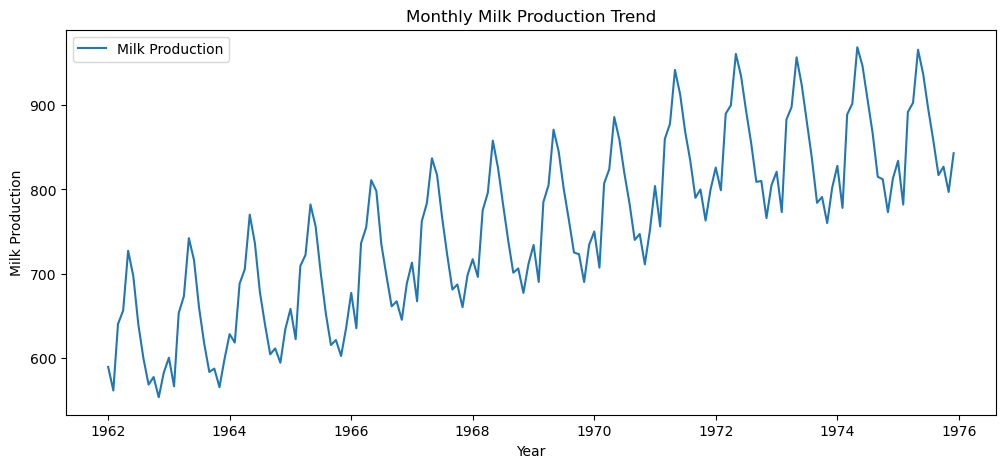

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df, label='Milk Production')
plt.title('Monthly Milk Production Trend')
plt.xlabel('Year')
plt.ylabel('Milk Production')
plt.legend()
plt.show()


In [18]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)


In [19]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12
X, y = create_sequences(scaled_data, WINDOW_SIZE)

X.shape, y.shape


((156, 12, 1), (156, 1))

In [20]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train.shape, X_test.shape


((124, 12, 1), (32, 12, 1))

In [21]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(WINDOW_SIZE,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

rnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.1376 - val_loss: 0.0177
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0370 - val_loss: 0.0097
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0119 - val_loss: 0.0512
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0099 - val_loss: 0.0114
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0066 - val_loss: 0.0037
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - val_loss: 0.0110
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0045 - val_loss: 0.0111
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0034 - val_loss: 0.0051
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0032 - val_loss: 0.0044
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0029 - val_loss: 0.0062


In [23]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(WINDOW_SIZE,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(WINDOW_SIZE,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.1161 - val_loss: 0.1395
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0353 - val_loss: 0.0264
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0286 - val_loss: 0.0225
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0269 - val_loss: 0.0266
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0221 - val_loss: 0.0410
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0227 - val_loss: 0.0411
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0214 - val_loss: 0.0296
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0207 - val_loss: 0.0241


In [26]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test)

    rmse = math.sqrt(mean_squared_error(actual, predictions))
    mae = mean_absolute_error(actual, predictions)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100

    return rmse, mae, mape, predictions, actual


In [27]:
rnn_rmse, rnn_mae, rnn_mape, rnn_pred, actual = evaluate_model(rnn_model, X_test, y_test)
lstm_rmse, lstm_mae, lstm_mape, lstm_pred, _ = evaluate_model(lstm_model, X_test, y_test)
gru_rmse, gru_mae, gru_mape, gru_pred, _ = evaluate_model(gru_model, X_test, y_test)

print("RNN  RMSE:", rnn_rmse, " MAE:", rnn_mae, " MAPE:", rnn_mape)
print("LSTM RMSE:", lstm_rmse," MAE:", lstm_mae," MAPE:", lstm_mape)
print("GRU  RMSE:", gru_rmse, " MAE:", gru_mae, " MAPE:", gru_mape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
RNN  RMSE: 32.61864067790288  MAE: 26.984922409057614  MAPE: 3.061395183566231
LSTM RMSE: 332.8234889971252  MAE: 327.05461502075195  MAPE: 37.89580754050756
GRU  RMSE: 63.747400021900006  MAE: 50.14065361022949  MAPE: 5.659698983913241


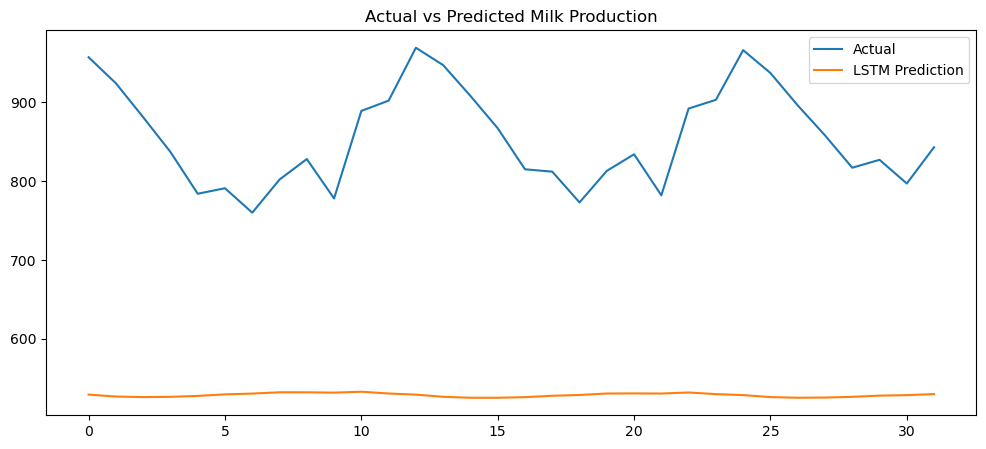

In [28]:
plt.figure(figsize=(12,5))
plt.plot(actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Prediction')
plt.title('Actual vs Predicted Milk Production')
plt.legend()
plt.show()


In [29]:
forecast_steps = 12
last_sequence = scaled_data[-WINDOW_SIZE:]

forecast = []

for _ in range(forecast_steps):
    pred = lstm_model.predict(last_sequence.reshape(1, WINDOW_SIZE, 1))
    forecast.append(pred[0,0])
    last_sequence = np.append(last_sequence[1:], pred, axis=0)

forecast = scaler.inverse_transform(np.array(forecast).reshape(-1,1))
forecast


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[529.7895 ],
       [538.23865],
       [542.25793],
       [545.28687],
       [547.5397 ],
       [549.22565],
       [550.45087],
       [551.3285 ],
       [551.9512 ],
       [552.3858 ],
       [552.71387],
       [552.94495]], dtype=float32)

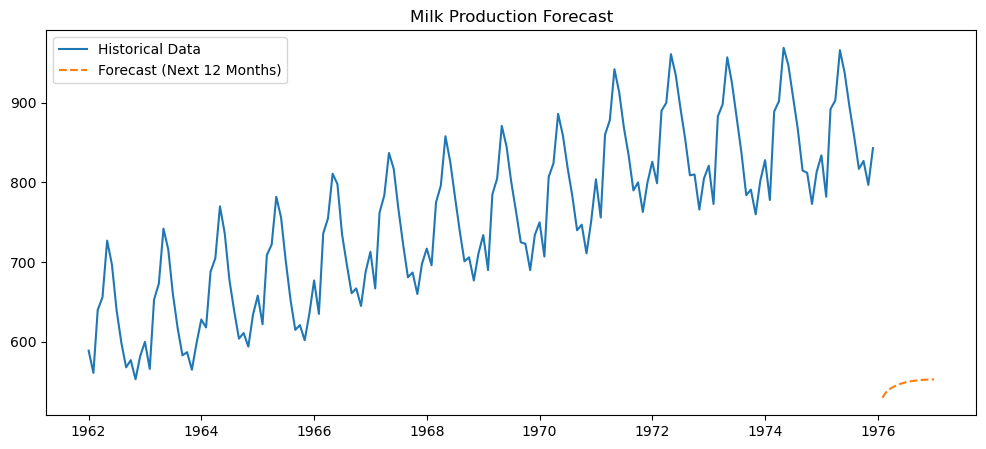

In [30]:
future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')

plt.figure(figsize=(12,5))
plt.plot(df, label='Historical Data')
plt.plot(future_dates, forecast, label='Forecast (Next 12 Months)', linestyle='--')
plt.title('Milk Production Forecast')
plt.legend()
plt.show()


In [31]:
print("""
Business Insights:
1. The model captures seasonal patterns in milk production effectively.
2. LSTM outperformed RNN and GRU in terms of RMSE and MAPE.
3. Forecasting helps in inventory planning and cold storage optimization.
4. Workforce scheduling can be aligned with peak production months.
5. Long-term forecasts support strategic expansion and demand planning.
""")



Business Insights:
1. The model captures seasonal patterns in milk production effectively.
2. LSTM outperformed RNN and GRU in terms of RMSE and MAPE.
3. Forecasting helps in inventory planning and cold storage optimization.
4. Workforce scheduling can be aligned with peak production months.
5. Long-term forecasts support strategic expansion and demand planning.

